In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

%matplotlib inline

In [49]:
df = pd.read_csv(r'TaxiNYC.csv')
df

,Unnamed: 0,timestamp,value
0,0,2014-07-01 00:00:00,10844
1,1,2014-07-01 00:30:00,8127
2,2,2014-07-01 01:00:00,6210
3,3,2014-07-01 01:30:00,4656
4,4,2014-07-01 02:00:00,3820
...,...,...,...
10315,10315,2015-01-31 21:30:00,24670
10316,10316,2015-01-31 22:00:00,25721
10317,10317,2015-01-31 22:30:00,27309
10318,10318,2015-01-31 23:00:00,26591


In [50]:
df = df.rename(columns={
    "Unnamed: 0":"Unique_ID",
    "value": "passengers"
})

In [51]:
df.columns

Index(['Unique_ID', 'timestamp', 'passengers'], dtype='object')

In [52]:
df.drop("Unique_ID",axis=1,inplace=True)

In [53]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')


In [54]:
df.set_index('timestamp', inplace=True)

In [55]:
df

,passengers
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820
...,...
2015-01-31 21:30:00,24670
2015-01-31 22:00:00,25721
2015-01-31 22:30:00,27309


In [56]:
train_size = int(len(df)* 0.8)

In [57]:
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (8256, 1)
Test shape: (2064, 1)


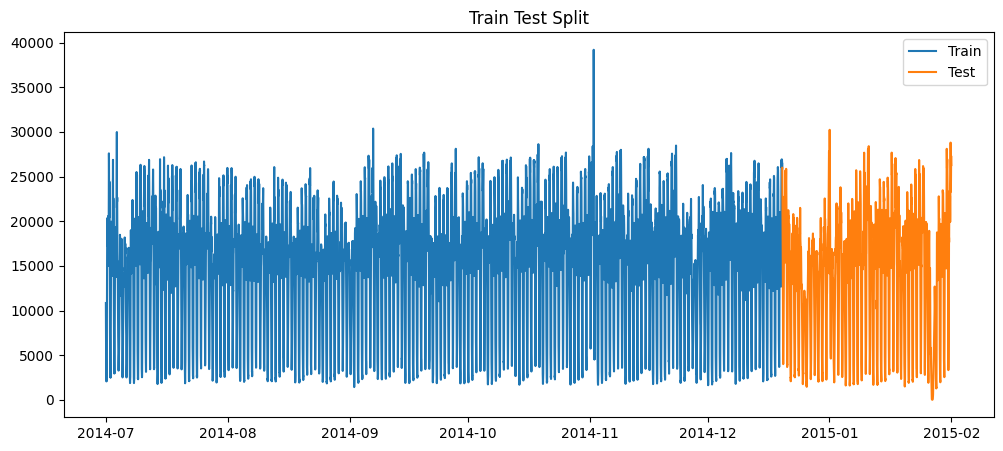

In [58]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['passengers'], label="Train")
plt.plot(test.index, test['passengers'], label="Test")
plt.legend()
plt.title("Train Test Split")
plt.show()

In [59]:
model = SARIMAX(
    train['passengers'],
    order=(1,1,1),
    seasonal_order=(1,1,1,48),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                 8256
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 48)   Log Likelihood              -66880.503
Date:                            Sun, 08 Mar 2026   AIC                         133771.006
Time:                                    04:21:20   BIC                         133806.039
Sample:                                07-01-2014   HQIC                        133782.985
                                     - 12-19-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6780      0.007     94.480      0.000       0.664       0.692
ma.L1         -0.2662      0.006   

In [60]:
forecast = results.predict(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)

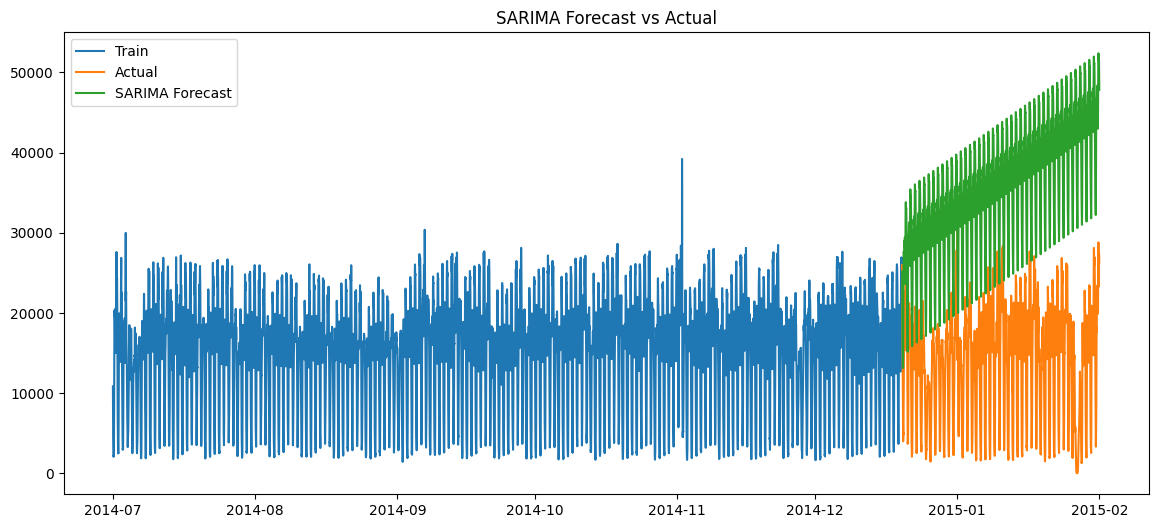

In [61]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train['passengers'], label="Train")
plt.plot(test.index, test['passengers'], label="Actual")
plt.plot(forecast.index, forecast, label="SARIMA Forecast")

plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()

In [62]:
mae = mean_absolute_error(test['passengers'], forecast)

print("MAE:", mae)

MAE: 22188.2471783793


In [63]:
residuals = test['passengers'] - forecast

In [68]:
residuals.mean()

-22180.127439677584

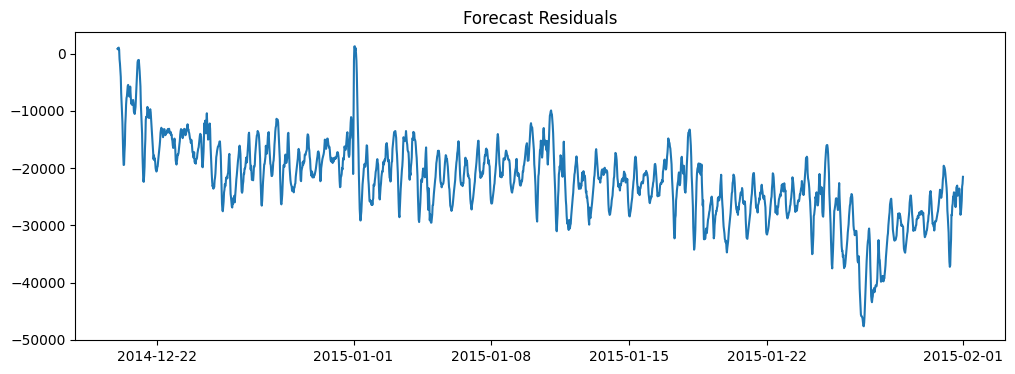

In [64]:
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Forecast Residuals")
plt.show()

In [65]:
threshold = 3 * np.std(residuals)

anomalies = residuals[np.abs(residuals) > threshold]

In [67]:
anomalies.mean()

-26328.639459319867

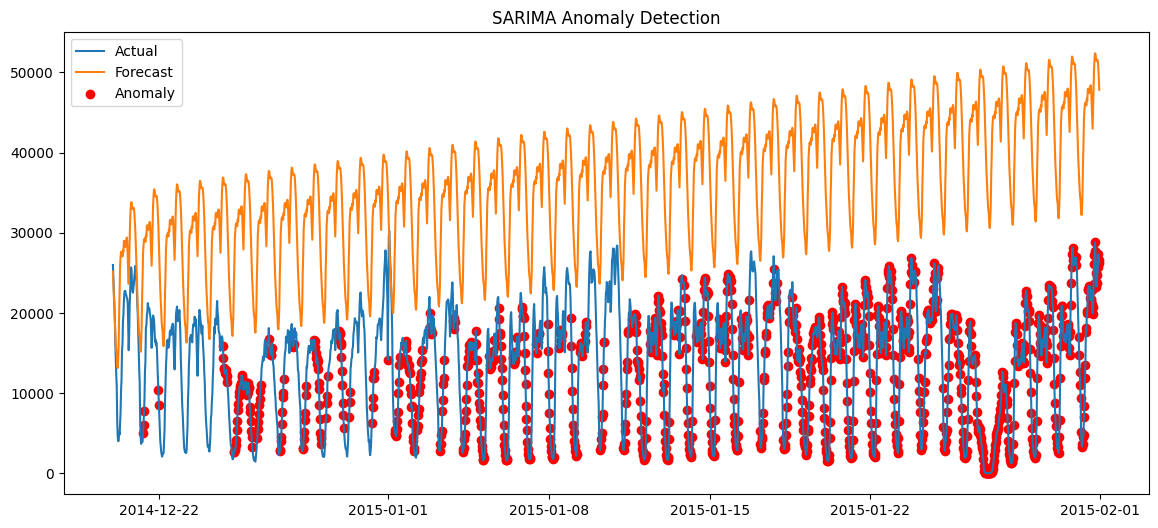

In [66]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test['passengers'], label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")

plt.scatter(
    anomalies.index,
    test.loc[anomalies.index]['passengers'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("SARIMA Anomaly Detection")
plt.show()